# Deteksi Warna

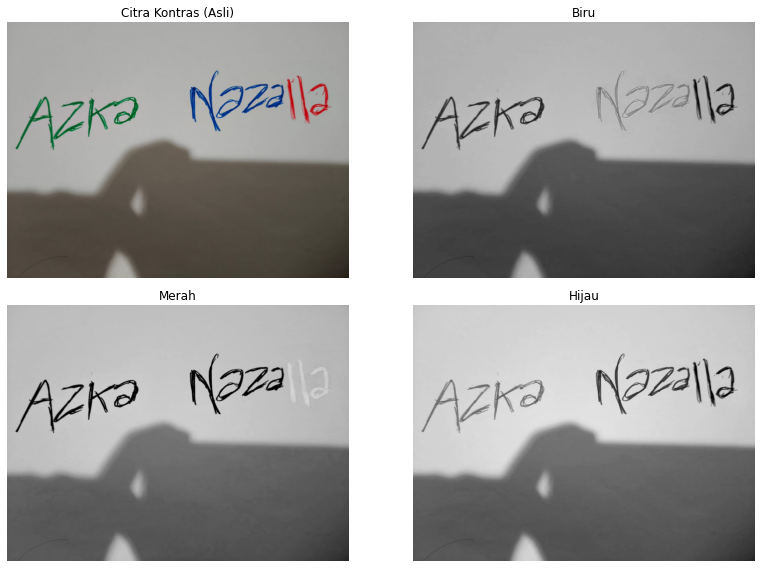

In [1]:
import cv2 
import matplotlib.pyplot as plt
import numpy as np

img = cv2.imread('NamaP.jpeg') 
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 

b, g, r = cv2.split(img)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title('Citra Kontras (Asli)')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(b, cmap='gray')
plt.title('Biru')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(r, cmap='gray')
plt.title('Merah')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(g, cmap='gray')
plt.title('Hijau')
plt.axis('off')

plt.tight_layout()
plt.show()

# Histogram

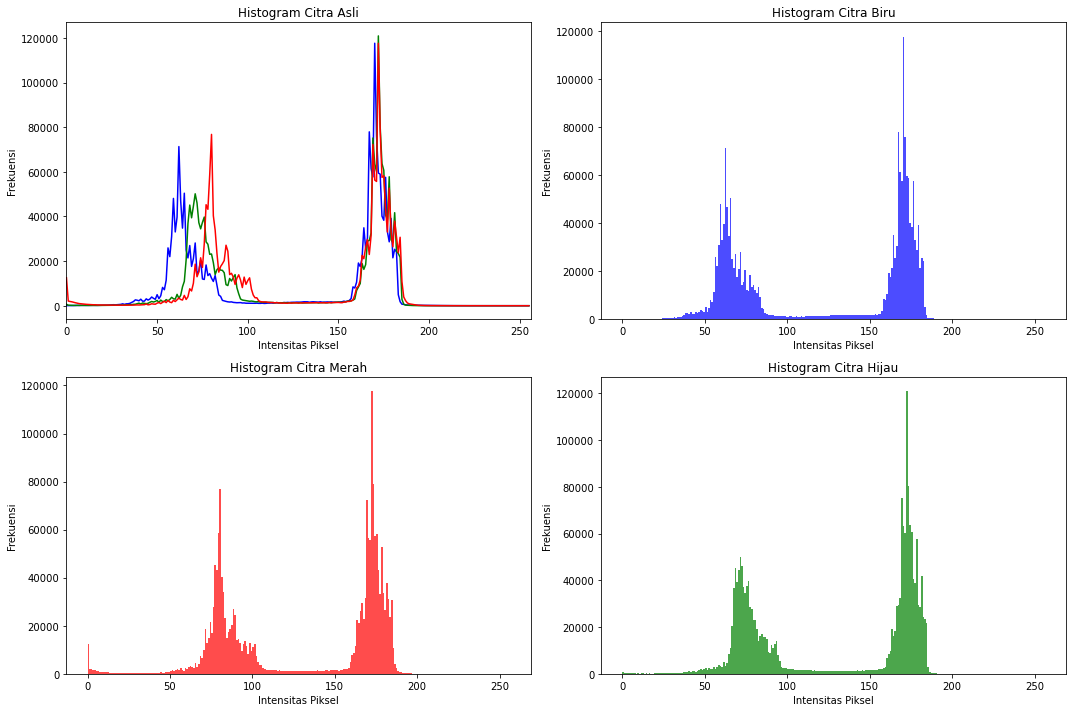

In [2]:
plt.figure(figsize=(15, 10))

# Histogram Citra Asli (3 Channel)
plt.subplot(2, 2, 1)
colors = ('b', 'g', 'r')
for i, col in enumerate(colors):
    hist = cv2.calcHist([img], [i], None, [256], [0, 256])
    plt.plot(hist, color=col)
    plt.xlim([0, 256])
plt.title('Histogram Citra Asli')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Frekuensi')

# Histogram Channel Biru
plt.subplot(2, 2, 2)
plt.hist(b.ravel(), 256, [0, 256], color='blue', alpha=0.7)
plt.title('Histogram Citra Biru')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Frekuensi')

# Histogram Channel Merah
plt.subplot(2, 2, 3)
plt.hist(r.ravel(), 256, [0, 256], color='red', alpha=0.7)
plt.title('Histogram Citra Merah')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Frekuensi')

# Histogram Channel Hijau
plt.subplot(2, 2, 4)
plt.hist(g.ravel(), 256, [0, 256], color='green', alpha=0.7)
plt.title('Histogram Citra Hijau')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

# Ambang Batas

In [3]:
img

array([[[158, 160, 160],
        [158, 160, 160],
        [158, 160, 160],
        ...,
        [152, 154, 154],
        [152, 154, 154],
        [152, 154, 154]],

       [[158, 160, 160],
        [158, 160, 160],
        [158, 160, 160],
        ...,
        [152, 154, 154],
        [152, 154, 154],
        [152, 154, 154]],

       [[158, 160, 160],
        [158, 160, 160],
        [158, 160, 160],
        ...,
        [152, 154, 154],
        [152, 154, 154],
        [152, 154, 154]],

       ...,

       [[ 58,  67,  76],
        [ 58,  67,  76],
        [ 58,  67,  76],
        ...,
        [ 20,  29,  33],
        [ 19,  28,  32],
        [ 19,  28,  32]],

       [[ 58,  67,  76],
        [ 58,  67,  76],
        [ 58,  67,  76],
        ...,
        [ 19,  28,  32],
        [ 19,  28,  32],
        [ 19,  28,  32]],

       [[ 57,  66,  75],
        [ 57,  66,  75],
        [ 57,  66,  75],
        ...,
        [ 19,  28,  32],
        [ 19,  28,  32],
        [ 19,  28,  32]]

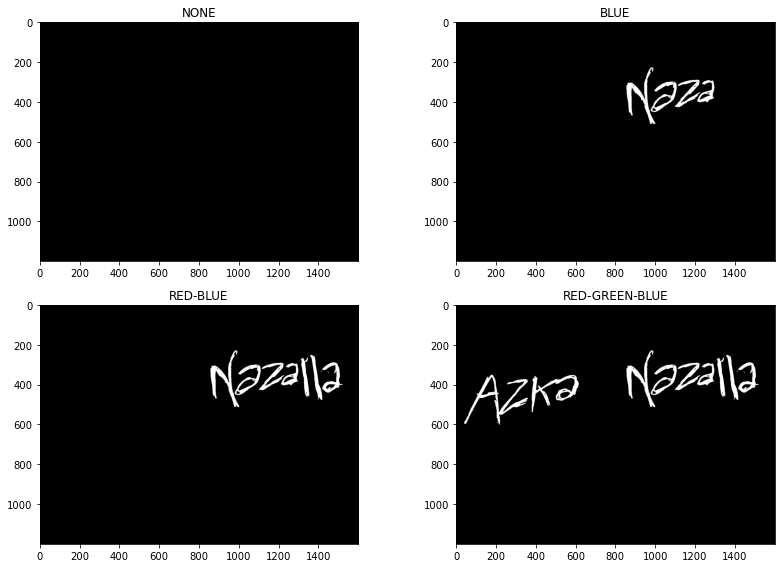

In [4]:
img = cv2.imread('NamaP.jpeg')
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# --- Biru ---
lower_blue = np.array([100, 50, 50])
upper_blue = np.array([140, 255, 255])
mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)

# --- Merah ---
lower_red1 = np.array([0, 50, 50])
upper_red1 = np.array([10, 255, 255])
mask_red1 = cv2.inRange(hsv, lower_red1, upper_red1)

lower_red2 = np.array([170, 50, 50])
upper_red2 = np.array([180, 255, 255])
mask_red2 = cv2.inRange(hsv, lower_red2, upper_red2)

mask_red = cv2.bitwise_or(mask_red1, mask_red2)

# --- Hijau ---
lower_green = np.array([40, 50, 50])
upper_green = np.array([80, 255, 255])
mask_green = cv2.inRange(hsv, lower_green, upper_green)


# Mask NONE (Semua hitam / array berisi nol)
mask_none = np.zeros_like(mask_blue)

# Mask RED-BLUE
mask_red_blue = cv2.bitwise_or(mask_red, mask_blue)

# Mask RED-GREEN-BLUE
mask_rgb_combined = cv2.bitwise_or(mask_red_blue, mask_green)


# Hasil
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(mask_none, cmap='gray')
plt.title('NONE')
plt.axis('on')

plt.subplot(2, 2, 2)
plt.imshow(mask_blue, cmap='gray')
plt.title('BLUE')
plt.axis('on')

plt.subplot(2, 2, 3)
plt.imshow(mask_red_blue, cmap='gray')
plt.title('RED-BLUE')
plt.axis('on')

plt.subplot(2, 2, 4)
plt.imshow(mask_rgb_combined, cmap='gray')
plt.title('RED-GREEN-BLUE')
plt.axis('on')

plt.tight_layout()
plt.show()

# Operasi Pixel

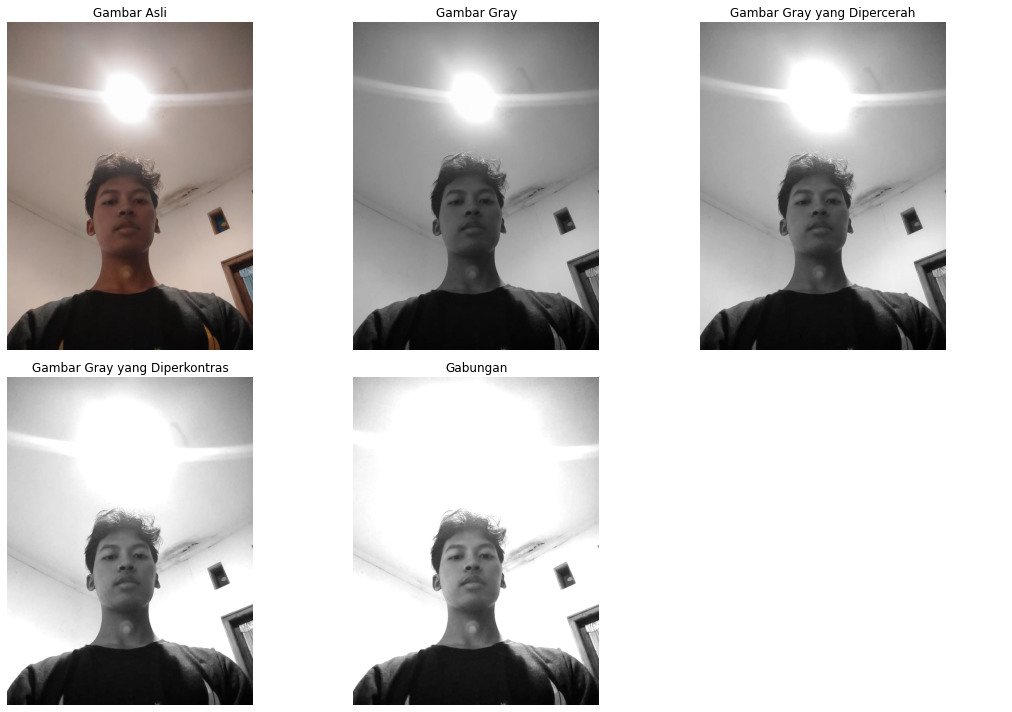

In [15]:
img = cv2.imread("Foto.jpeg")
img_asli = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 

img_abu = cv2.cvtColor(img_asli, cv2.COLOR_RGB2GRAY)

alpha = 1.5  
beta = 40    

img_cerah = np.clip(img_abu.astype(float) + beta, 0, 255).astype(np.uint8)

img_kontras = np.clip(img_abu.astype(float) * alpha, 0, 255).astype(np.uint8)

img_gabungan = np.clip((img_abu.astype(float) * alpha) + beta, 0, 255).astype(np.uint8)

# UBAH GRID MENJADI 2x3 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# 1. Gambar Asli Berwarna
axs[0, 0].imshow(img_asli)
axs[0, 0].set_title("Gambar Asli")
axs[0, 0].axis('off')

# 2. Gambar Gray Asli
axs[0, 1].imshow(img_abu, cmap='gray')
axs[0, 1].set_title("Gambar Gray")
axs[0, 1].axis('off')

# 3. Gambar Gray yang Dipercerah
axs[0, 2].imshow(img_cerah, cmap='gray')
axs[0, 2].set_title("Gambar Gray yang Dipercerah")
axs[0, 2].axis('off')

# 4. Gambar Gray yang Diperkontras
axs[1, 0].imshow(img_kontras, cmap='gray')
axs[1, 0].set_title("Gambar Gray yang Diperkontras")
axs[1, 0].axis('off')

# 5. Gambar Gabungan
axs[1, 1].imshow(img_gabungan, cmap='gray')
axs[1, 1].set_title("Gabungan")
axs[1, 1].axis('off')
axs[1, 2].axis('off')

plt.tight_layout()
plt.show()